In [14]:
import json
import torch
import numpy as np
import random
import os
import pandas as pd
import sys
import random
import math
import argparse
import yaml
from pathlib import Path
import datetime
import wandb

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import plotly.graph_objects as go

from typing import List, Optional
import fire

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from typing import List

from fairscale.nn.model_parallel.initialize import (
    get_model_parallel_rank,
    initialize_model_parallel,
    model_parallel_is_initialized,
)

from collections import Counter

In [15]:
######################################################

# Parser
curr_date = datetime.datetime.now().strftime("%Y%m%d")

pre_parser = argparse.ArgumentParser(description="Config Loader", add_help=False)
pre_parser.add_argument("--config", type=str, default="train_encoders_and_decoders_default_config.yaml", help="Path to YAML configuration file")
pre_parser.add_argument("--master_port", type=int, default=29500, help="Port for distributed init (must be unique per job)")
pre_parser.add_argument("--run_name", type=str, default=curr_date, help="Name of run (used for wandb and to save model files)")


config_args, remaining_argv = pre_parser.parse_known_args()

with open(config_args.config, "r") as f:
    config_defaults = yaml.safe_load(f)

master_port = str(config_args.master_port)
run_name    = config_args.run_name

# --- Full CLI parser with YAML defaults ---
parser = argparse.ArgumentParser(description="Train Encoders and Decoders")
parser.add_argument("--config", type=str, default="train_encoders_and_decoders_default_config.yaml", help="Path to YAML configuration file")

# === Path config ===
parser.add_argument("--curr_dir", type=str, default=config_defaults.get("curr_dir"), help="Path to program root")
parser.add_argument("--git_dir", type=str, default=config_defaults.get("git_dir"), help="Path to project Git root")
parser.add_argument("--chpt_dir", type=str, default=config_defaults.get("chpt_dir"), help="Path to LLM checkpoint directory")
parser.add_argument("--tokenizer_path", type=str, default=config_defaults.get("tokenizer_path"), help="Path to tokenizer.model file")
parser.add_argument("--generate_data", type=int, default=config_defaults.get("generate_data"), help="Whether to generate training data")
parser.add_argument("--log_wandb", type=int, default=config_defaults.get("log_wandb"), help="Whether to log outputs to wandb")

# === Model config ===
parser.add_argument("--max_seq_len", type=int, default=config_defaults.get("max_seq_len"), help="Max sequence length for LLM")
parser.add_argument("--max_batch_size", type=int, default=config_defaults.get("max_batch_size"), help="Batch size for LLM generation")
parser.add_argument("--model_parallel_size", type=int, default=config_defaults.get("model_parallel_size"), help="Model parallelism size")
parser.add_argument("--model_dim", type=int, default=config_defaults.get("model_dim"), help="Model dimension (hidden size)")

# === Generation params ===
parser.add_argument("--top_p", type=float, default=config_defaults.get("top_p"), help="Nucleus sampling probability threshold")
parser.add_argument("--temperature", type=float, default=config_defaults.get("temperature"), help="Sampling temperature")
parser.add_argument("--max_gen_len", type=int, default=config_defaults.get("max_gen_len"), help="Maximum number of tokens to generate")

# === Symbolic Engine ===
parser.add_argument("--max_digits", type=int, default=config_defaults.get("max_digits"), help="Max number of digits to encode")
parser.add_argument("--VSA_dim", type=int, default=config_defaults.get("VSA_dim"), help="VSA dimensionality")
parser.add_argument("--possible_problems", nargs="+", type=str, default=config_defaults.get("possible_problems"), help="All problem types symbolic engine should support")

# === Data generation ===
parser.add_argument("--train_data_rounds", type=int, default=config_defaults.get("train_data_rounds"), help="Number of training queries to LLM")
parser.add_argument("--val_data_rounds", type=int, default=config_defaults.get("val_data_rounds"), help="Number of validation queries to LLM")
parser.add_argument("--test_data_rounds", type=int, default=config_defaults.get("test_data_rounds"), help="Number of test queries to LLM")
parser.add_argument("--restrict_train_dataset", type=int, default=config_defaults.get("restrict_train_dataset"), help="Number of queries to load to train encoders and decoders")
parser.add_argument("--restrict_val_dataset", type=int, default=config_defaults.get("restrict_val_dataset"), help="Number of queries to load to validation encoders and decoders")
parser.add_argument("--restrict_test_dataset", type=int, default=config_defaults.get("restrict_test_dataset"), help="Number of queries to load to test encoders and decoders")
parser.add_argument("--save_frequency", type=int, default=config_defaults.get("save_frequency"), help="Save hidden/VSA data every N batches")
parser.add_argument("--layer_numbers", type=int, nargs="+", default=config_defaults.get("layer_numbers"), help="Layers to train encoders/decoders for")
parser.add_argument("--complexity", type=int, default=config_defaults.get("complexity"), help="Problem complexity = digits + 1")
parser.add_argument("--n_samples", type=int, default=config_defaults.get("n_samples"), help="Number of samples to use per forward pass")
parser.add_argument("--problem_type", nargs="+", type=str, default=config_defaults.get("problem_type"), help="Subset of problem types to use for training")

# === Token handling ===
parser.add_argument("--tokens_to_keep", type=str, default=config_defaults.get("tokens_to_keep"), help="How many tokens to keep (or 'all')")
parser.add_argument("--calculate_end_index", type=int, default=config_defaults.get("calculate_end_index"), help="Whether to cut tokens at the end of the prompt")

# === Encoder/Decoder training ===
parser.add_argument("--encoder_decoder_batch_size", type=int, default=config_defaults.get("encoder_decoder_batch_size"), help="Training batch size")
parser.add_argument("--training_epochs", type=int, default=config_defaults.get("training_epochs"), help="Number of epochs for encoder training")
parser.add_argument("--learning_rate", type=float, default=config_defaults.get("learning_rate"), help="Base learning rate for encoder")
parser.add_argument("--learning_rate_reduction_factors", type=json.loads, default=config_defaults.get("learning_rate_reduction_factors"), help="Epoch:Factor map for reducing LR")
parser.add_argument("--train_freq_print", type=int, default=config_defaults.get("train_freq_print"), help="Frequency of print statements during training")

parser.add_argument("--decoding_epochs", type=int, default=config_defaults.get("decoding_epochs"), help="Number of epochs for decoder training")
parser.add_argument("--decoding_learning_rate", type=float, default=config_defaults.get("decoding_learning_rate"), help="Base learning rate for decoder")
parser.add_argument("--decoding_learning_rate_reduction_factors", type=json.loads, default=config_defaults.get("decoding_learning_rate_reduction_factors"), help="Epoch:Factor map for reducing decoder LR")

parser.add_argument("--training_data_df_path", type=str, default=config_defaults.get("training_data_df_path"), help="Path to pre-generated training dataset (leave as '' to run based on randomly sampled data)")
parser.add_argument("--val_data_df_path", type=str, default=config_defaults.get("val_data_df_path"), help="Path to pre-generated validation dataset (leave as '' to run based on randomly sampled data)")
parser.add_argument("--testing_data_df_path", type=str, default=config_defaults.get("testing_data_df_path"), help="Path to pre-generated testing dataset (leave as '' to run based on randomly sampled data)")


_StoreAction(option_strings=['--testing_data_df_path'], dest='testing_data_df_path', nargs=None, const=None, default='', type=<class 'str'>, choices=None, help="Path to pre-generated testing dataset (leave as '' to run based on randomly sampled data)", metavar=None)

In [16]:
args = parser.parse_args([])


In [17]:
# --- Step 5: Expand and assign ---
curr_dir       = str(Path(args.curr_dir).expanduser())
git_dir        = str(Path(args.git_dir ).expanduser())
ckpt_dir       = str(Path(args.chpt_dir).expanduser())
tokenizer_path = str(Path(args.tokenizer_path).expanduser())
generate_data  = args.generate_data
log_wandb      = args.log_wandb

# Model + sampling
max_seq_len         = args.max_seq_len
max_batch_size      = args.max_batch_size
model_parallel_size = args.model_parallel_size
model_dim           = args.model_dim

top_p        = args.top_p
temperature  = args.temperature
max_gen_len  = args.max_gen_len

# Symbolic engine
max_digits         = args.max_digits
VSA_dim            = args.VSA_dim
possible_problems  = args.possible_problems

# Data collection
train_data_rounds      = args.train_data_rounds
val_data_rounds        = args.val_data_rounds
test_data_rounds       = args.test_data_rounds
restrict_train_dataset = args.restrict_train_dataset
restrict_val_dataset   = args.restrict_val_dataset
restrict_test_dataset  = args.restrict_test_dataset
save_frequency         = args.save_frequency
layer_numbers          = torch.tensor(args.layer_numbers)
complexity             = args.complexity
n_samples              = args.n_samples
problem_type           = args.problem_type

# Tokenization
tokens_to_keep      = args.tokens_to_keep if args.tokens_to_keep == "all" else int(args.tokens_to_keep)
calculate_end_index = args.calculate_end_index

# Encoder/decoder training
encoder_decoder_batch_size               = args.encoder_decoder_batch_size
training_epochs                          = args.training_epochs
learning_rate                            = args.learning_rate
learning_rate_reduction_factors          = args.learning_rate_reduction_factors
train_freq_print                         = args.train_freq_print

decoding_training_epochs                 = args.decoding_epochs
decoding_learning_rate                   = args.decoding_learning_rate
decoding_learning_rate_reduction_factors = args.decoding_learning_rate_reduction_factors

training_data_df_path = str(Path(args.training_data_df_path).expanduser()) if args.training_data_df_path else ''
val_data_df_path      = str(Path(args.val_data_df_path).expanduser()) if args.val_data_df_path else ''
testing_data_df_path  = str(Path(args.testing_data_df_path).expanduser()) if args.testing_data_df_path else ''


In [18]:
######################################################

sys.path.insert(0, git_dir)

from llama.encoder_decoder_networks import Encoder, Decoder, Encoder_Deep, Decoder_Deep, LastTokenTransformer
from llama.vsa_engine import *
from llama.utilities import *

from llama import Llama

######################################################


In [19]:
log_wandb = False
run_name = "linear_encoder_3_digit_data_pre_generated_dataset_x_gt_y_gpu_seeded"
generate_data = 0

training_data_df_path = str(Path("~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_20000_training_samples.csv").expanduser())
val_data_df_path = str(Path("~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_200_validation_samples.csv").expanduser())
testing_data_df_path = str(Path("~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_2000_testing_samples.csv").expanduser())


if log_wandb:
    wandb.finish() # If there is an active current run, terminate it
    if generate_data:
        wandb.init(
            project = "Symbolic LLM - Generate Encoder Input Data",
            name    = run_name,
        )
    else:
        wandb.init(
            project = "Symbolic LLM - Train Encoders and Decoders",
            name    = run_name,
        )

print("Run:", run_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", torch.cuda.get_device_name(torch.cuda.current_device()))

if generate_data:
    os.environ['RANK'] = "0"
    os.environ['WORLD_SIZE'] = "1"
    os.environ['MASTER_ADDR'] = "127.0.0.2"
    os.environ['MASTER_PORT'] = master_port
    os.environ['LOCAL_RANK']  = "0"
    os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
    os.environ['TORCH_USE_CUDA_DSA'] = "1"

    generator = Llama.build(
        ckpt_dir=ckpt_dir,
        tokenizer_path=tokenizer_path,
        max_seq_len=max_seq_len,
        max_batch_size=max_batch_size,
    )

    for param in generator.model.parameters():
        param.requires_grad = False
else:
    if torch.cuda.is_bf16_supported():
        torch.set_default_dtype(torch.bfloat16)
    else:
        torch.set_default_dtype(torch.float16)

    torch.set_default_device("cuda")



possible_problems_str = "_".join(possible_problems)

if os.path.exists(f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt"):
    SE = torch.load(f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}"
                    f"_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt", weights_only=False)
else:
    SE = SymbolicEngine(VSA_dim=VSA_dim, max_digits=max_digits, possible_problems=possible_problems, 
                        curr_dir=curr_dir)
    torch.save(SE, f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt")

if type(problem_type) == type([]):
    problem_str = "_".join(problem_type)
else:
    problem_str = problem_type

    
    
if training_data_df_path:
    print("training_data_df_path:",training_data_df_path)
    df_train = pd.read_csv(training_data_df_path)
    train_data_rounds = len(df_train) // n_samples
    print("Set number of training rounds to:", train_data_rounds)
    if train_data_rounds % save_frequency:
        print("Warning: number of training rounds is not divisible by save_frequency. This will cause an error during dataset generation. Exiting...")
        sys.exit()

    if len(df_train) % n_samples:
        print(f"Warning: size of predefined training dataframe ({len(df_train)}) is not divisible by the LLM batch size ({n_samples}). Some rows in the dataframe will not be processed")
else:
    df_train = None

if val_data_df_path:
    df_val = pd.read_csv(val_data_df_path)
    val_data_rounds = len(df_val) // n_samples
    print("Set number of validation rounds to:", val_data_rounds)
    if val_data_rounds % save_frequency:
        print("Warning: number of validation rounds is not divisible by save_frequency. This will cause an error during dataset generation. Exiting...")
        sys.exit()

    if len(df_val) % n_samples:
        print(f"Warning: size of predefined validation dataframe ({len(df_val)}) is not divisible by the LLM batch size ({n_samples}). Some rows in the dataframe will not be processed")
else:
    df_val = None

if testing_data_df_path:
    df_test = pd.read_csv(testing_data_df_path)
    test_data_rounds = len(df_test) // n_samples
    print("Set number of testing rounds to:", test_data_rounds)
    if test_data_rounds % save_frequency:
        print("Warning: number of testing rounds is not divisible by save_frequency. This will cause an error during dataset generation. Exiting...")
        sys.exit()

    if len(df_test) % n_samples:
        print(f"Warning: size of predefined testing dataframe ({len(df_test)}) is not divisible by the LLM batch size ({n_samples}). Some rows in the dataframe will not be processed")
else:
    df_test = None

    
# Output directory to write and read saved hidden state and VSA data to
#save_dir = f"{curr_dir}/gathered_data-{complexity}_complexity-{tokens_to_keep}_tokens_kept-{calculate_end_index}_cei-{train_data_rounds}_train_rounds-{val_data_rounds}_val_rounds-{test_data_rounds}_test_rounds-{problem_str}"
save_dir = f"gathered_data_{run_name}"


os.makedirs(save_dir, exist_ok=True)
print("Data will be saved and read from:", save_dir)

if generate_data:
    generate_and_save_data(generator=generator, SE=SE, save_dir=save_dir, 
                           rounds=train_data_rounds, mode="train",  save_frequency=save_frequency,
                           complexity=complexity, n_samples=n_samples, problem_type=problem_type, df_subset=df_train,
                           tokens_to_keep=tokens_to_keep, calculate_end_index=calculate_end_index, verbose=True)
    print("Training data gathering completed and saved to disk.")

    generate_and_save_data(generator=generator, SE=SE, save_dir=save_dir, 
                           rounds=val_data_rounds,  mode="val", save_frequency=save_frequency,
                           complexity=complexity, n_samples=n_samples, problem_type=problem_type, df_subset=df_val,
                           tokens_to_keep=tokens_to_keep, calculate_end_index=calculate_end_index, verbose=True)
    print("Validation data gathering completed and saved to disk.")

    generate_and_save_data(generator=generator, SE=SE, save_dir=save_dir, 
                           rounds=test_data_rounds,  mode="test", save_frequency=save_frequency,
                           complexity=complexity, n_samples=n_samples, problem_type=problem_type, df_subset=df_test,
                           tokens_to_keep=tokens_to_keep, calculate_end_index=calculate_end_index, verbose=True)
    print("Testing data gathering completed and saved to disk.")

if not generate_data:
    training_encoder_data_loaders_pregenerated = generate_data_loaders(mode='train', save_dir=save_dir, data_rounds=train_data_rounds, n_samples=n_samples, df_subset=df_train,
                                                          save_frequency=save_frequency, layer_numbers=layer_numbers, restrict_dataset=restrict_train_dataset, 
                                                          tokens_to_keep=tokens_to_keep, batch_size=encoder_decoder_batch_size, verbose=True)
    print("Training data loaders for each layer have been created.")

    validation_encoder_data_loaders_pregenerated = generate_data_loaders(mode='val', save_dir=save_dir, data_rounds=val_data_rounds, n_samples=n_samples, df_subset=df_val,
                                                            save_frequency=save_frequency, layer_numbers=layer_numbers, restrict_dataset=restrict_val_dataset, 
                                                            tokens_to_keep=tokens_to_keep, batch_size=encoder_decoder_batch_size, verbose=True)
    print("Validation data loaders for each layer have been created.")

    testing_encoder_data_loaders_pregenerated = generate_data_loaders(mode='test', save_dir=save_dir, data_rounds=test_data_rounds, n_samples=n_samples, df_subset=df_test,
                                                         save_frequency=save_frequency, layer_numbers=layer_numbers, restrict_dataset=restrict_test_dataset, 
                                                         tokens_to_keep=tokens_to_keep, batch_size=encoder_decoder_batch_size, verbose=True)
    print("Testing data loaders for each layer have been created.")




Run: linear_encoder_3_digit_data_pre_generated_dataset_x_gt_y_gpu_seeded
Current device: NVIDIA RTX 6000 Ada Generation
training_data_df_path: /u4/vdhanraj/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_20000_training_samples.csv
Set number of training rounds to: 10000
Set number of validation rounds to: 100
Set number of testing rounds to: 1000
Data will be saved and read from: gathered_data_linear_encoder_3_digit_data_pre_generated_dataset_x_gt_y_gpu_seeded
--- On Layer Number: 0
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
On Round Number: 1050
On Round Number: 1100
On Round Number: 1150
O

On Round Number: 8700
On Round Number: 8750
On Round Number: 8800
On Round Number: 8850
On Round Number: 8900
On Round Number: 8950
On Round Number: 9000
On Round Number: 9050
On Round Number: 9100
On Round Number: 9150
On Round Number: 9200
On Round Number: 9250
On Round Number: 9300
On Round Number: 9350
On Round Number: 9400
On Round Number: 9450
On Round Number: 9500
On Round Number: 9550
On Round Number: 9600
On Round Number: 9650
On Round Number: 9700
On Round Number: 9750
On Round Number: 9800
On Round Number: 9850
On Round Number: 9900
On Round Number: 9950
On Round Number: 10000
--- On Layer Number: 2
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Ro

On Round Number: 8400
On Round Number: 8450
On Round Number: 8500
On Round Number: 8550
On Round Number: 8600
On Round Number: 8650
On Round Number: 8700
On Round Number: 8750
On Round Number: 8800
On Round Number: 8850
On Round Number: 8900
On Round Number: 8950
On Round Number: 9000
On Round Number: 9050
On Round Number: 9100
On Round Number: 9150
On Round Number: 9200
On Round Number: 9250
On Round Number: 9300
On Round Number: 9350
On Round Number: 9400
On Round Number: 9450
On Round Number: 9500
On Round Number: 9550
On Round Number: 9600
On Round Number: 9650
On Round Number: 9700
On Round Number: 9750
On Round Number: 9800
On Round Number: 9850
On Round Number: 9900
On Round Number: 9950
On Round Number: 10000
--- On Layer Number: 4
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600

On Round Number: 9350
On Round Number: 9400
On Round Number: 9450
On Round Number: 9500
On Round Number: 9550
On Round Number: 9600
On Round Number: 9650
On Round Number: 9700
On Round Number: 9750
On Round Number: 9800
On Round Number: 9850
On Round Number: 9900
On Round Number: 9950
On Round Number: 10000
--- On Layer Number: 6
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
On Round Number: 1050
On Round Number: 1100
On Round Number: 1150
On Round Number: 1200
On Round Number: 1250
On Round Number: 1300
On Round Number: 1350
On Round Number: 1400
On Round Number: 1450
On Round Number: 1500
On Round Number: 1550
On Rou

On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
On Round Number: 1050
On Round Number: 1100
On Round Number: 1150
On Round Number: 1200
On Round Number: 1250
On Round Number: 1300
On Round Number: 1350
On Round Number: 1400
On Round Number: 1450
On Round Number: 1500
On Round Number: 1550
On Round Number: 1600
On Round Number: 1650
On Round Number: 1700
On Round Number: 1750
On Round Number: 1800
On Round Number: 1850
On Round Number: 1900
On Round Number: 1950
On Round Number: 2000
On Round Number: 2050
On Round Number: 2100
On Round Number: 2150
On Round Number: 2200
On Round Number: 2250
On Round Number: 2300
On Round Number: 2350
On Round Number: 2400
On Round Number: 2450
On Round Number: 2500
On Round Number: 2550
On

...

On Round Number: 9900
On Round Number: 9950
On Round Number: 10000
--- On Layer Number: 28
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
On Round Number: 1050
On Round Number: 1100
On Round Number: 1150
On Round Number: 1200
On Round Number: 1250
On Round Number: 1300
On Round Number: 1350
On Round Number: 1400
On Round Number: 1450
On Round Number: 1500
On Round Number: 1550
On Round Number: 1600
On Round Number: 1650
On Round Number: 1700
On Round Number: 1750
On Round Number: 1800
On Round Number: 1850
On Round Number: 1900
On Round Number: 1950
On Round Number: 2000
On Round Number: 2050
On Round Number: 2100
On Ro

On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
On Round Number: 1050
On Round Number: 1100
On Round Number: 1150
On Round Number: 1200
On Round Number: 1250
On Round Number: 1300
On Round Number: 1350
On Round Number: 1400
On Round Number: 1450
On Round Number: 1500
On Round Number: 1550
On Round Number: 1600
On Round Number: 1650
On Round Number: 1700
On Round Number: 1750
On Round Number: 1800
On Round Number: 1850
On Round Number: 1900
On Round Number: 1950
On Round Number: 2000
On Round Number: 2050
On Round Number: 2100
On Round Number: 2150
On Round Number: 2200
On Round Number: 2250
On Round Number: 2300
On Round Number: 2350
On Round Number: 2400
On Round Number: 2450
On Round Number: 2500
On Round Number: 2550
On Round Number: 2600
On Round Number: 2650
On Round Number: 2700
On Round Number: 2750
On Round Number: 2800
On Round Number: 2850
On Round Number: 2900
On Round Number: 2950
On Round Number

On Round Number: 1500
On Round Number: 1550
On Round Number: 1600
On Round Number: 1650
On Round Number: 1700
On Round Number: 1750
On Round Number: 1800
On Round Number: 1850
On Round Number: 1900
On Round Number: 1950
On Round Number: 2000
On Round Number: 2050
On Round Number: 2100
On Round Number: 2150
On Round Number: 2200
On Round Number: 2250
On Round Number: 2300
On Round Number: 2350
On Round Number: 2400
On Round Number: 2450
On Round Number: 2500
On Round Number: 2550
On Round Number: 2600
On Round Number: 2650
On Round Number: 2700
On Round Number: 2750
On Round Number: 2800
On Round Number: 2850
On Round Number: 2900
On Round Number: 2950
On Round Number: 3000
On Round Number: 3050
On Round Number: 3100
On Round Number: 3150
On Round Number: 3200
On Round Number: 3250
On Round Number: 3300
On Round Number: 3350
On Round Number: 3400
On Round Number: 3450
On Round Number: 3500
On Round Number: 3550
On Round Number: 3600
On Round Number: 3650
On Round Number: 3700
On Round N

On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
--- On Layer Number: 7
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
--- On Layer Number: 8
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round 

On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
--- On Layer Number: 26
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
--- On Layer Number: 27
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Roun

In [20]:
log_wandb = False
run_name = "linear_encoder_3_digit_data_randomly_generated_dataset_10k_20250516"
generate_data = 0

training_data_df_path = ""
val_data_df_path = ""
testing_data_df_path = ""


if log_wandb:
    wandb.finish() # If there is an active current run, terminate it
    if generate_data:
        wandb.init(
            project = "Symbolic LLM - Generate Encoder Input Data",
            name    = run_name,
        )
    else:
        wandb.init(
            project = "Symbolic LLM - Train Encoders and Decoders",
            name    = run_name,
        )

print("Run:", run_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", torch.cuda.get_device_name(torch.cuda.current_device()))

if generate_data:
    os.environ['RANK'] = "0"
    os.environ['WORLD_SIZE'] = "1"
    os.environ['MASTER_ADDR'] = "127.0.0.2"
    os.environ['MASTER_PORT'] = master_port
    os.environ['LOCAL_RANK']  = "0"
    os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
    os.environ['TORCH_USE_CUDA_DSA'] = "1"

    generator = Llama.build(
        ckpt_dir=ckpt_dir,
        tokenizer_path=tokenizer_path,
        max_seq_len=max_seq_len,
        max_batch_size=max_batch_size,
    )

    for param in generator.model.parameters():
        param.requires_grad = False
else:
    if torch.cuda.is_bf16_supported():
        torch.set_default_dtype(torch.bfloat16)
    else:
        torch.set_default_dtype(torch.float16)

    torch.set_default_device("cuda")



possible_problems_str = "_".join(possible_problems)

if os.path.exists(f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt"):
    SE = torch.load(f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}"
                    f"_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt", weights_only=False)
else:
    SE = SymbolicEngine(VSA_dim=VSA_dim, max_digits=max_digits, possible_problems=possible_problems, 
                        curr_dir=curr_dir)
    torch.save(SE, f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt")

if type(problem_type) == type([]):
    problem_str = "_".join(problem_type)
else:
    problem_str = problem_type

    
    
if training_data_df_path:
    print("training_data_df_path:",training_data_df_path)
    df_train = pd.read_csv(training_data_df_path)
    train_data_rounds = len(df_train) // n_samples
    print("Set number of training rounds to:", train_data_rounds)
    if train_data_rounds % save_frequency:
        print("Warning: number of training rounds is not divisible by save_frequency. This will cause an error during dataset generation. Exiting...")
        sys.exit()

    if len(df_train) % n_samples:
        print(f"Warning: size of predefined training dataframe ({len(df_train)}) is not divisible by the LLM batch size ({n_samples}). Some rows in the dataframe will not be processed")
else:
    df_train = None

if val_data_df_path:
    df_val = pd.read_csv(val_data_df_path)
    val_data_rounds = len(df_val) // n_samples
    print("Set number of validation rounds to:", val_data_rounds)
    if val_data_rounds % save_frequency:
        print("Warning: number of validation rounds is not divisible by save_frequency. This will cause an error during dataset generation. Exiting...")
        sys.exit()

    if len(df_val) % n_samples:
        print(f"Warning: size of predefined validation dataframe ({len(df_val)}) is not divisible by the LLM batch size ({n_samples}). Some rows in the dataframe will not be processed")
else:
    df_val = None

if testing_data_df_path:
    df_test = pd.read_csv(testing_data_df_path)
    test_data_rounds = len(df_test) // n_samples
    print("Set number of testing rounds to:", test_data_rounds)
    if test_data_rounds % save_frequency:
        print("Warning: number of testing rounds is not divisible by save_frequency. This will cause an error during dataset generation. Exiting...")
        sys.exit()

    if len(df_test) % n_samples:
        print(f"Warning: size of predefined testing dataframe ({len(df_test)}) is not divisible by the LLM batch size ({n_samples}). Some rows in the dataframe will not be processed")
else:
    df_test = None

    
# Output directory to write and read saved hidden state and VSA data to
#save_dir = f"{curr_dir}/gathered_data-{complexity}_complexity-{tokens_to_keep}_tokens_kept-{calculate_end_index}_cei-{train_data_rounds}_train_rounds-{val_data_rounds}_val_rounds-{test_data_rounds}_test_rounds-{problem_str}"
save_dir = f"gathered_data_{run_name}"


os.makedirs(save_dir, exist_ok=True)
print("Data will be saved and read from:", save_dir)

if generate_data:
    generate_and_save_data(generator=generator, SE=SE, save_dir=save_dir, 
                           rounds=train_data_rounds, mode="train",  save_frequency=save_frequency,
                           complexity=complexity, n_samples=n_samples, problem_type=problem_type, df_subset=df_train,
                           tokens_to_keep=tokens_to_keep, calculate_end_index=calculate_end_index, verbose=True)
    print("Training data gathering completed and saved to disk.")

    generate_and_save_data(generator=generator, SE=SE, save_dir=save_dir, 
                           rounds=val_data_rounds,  mode="val", save_frequency=save_frequency,
                           complexity=complexity, n_samples=n_samples, problem_type=problem_type, df_subset=df_val,
                           tokens_to_keep=tokens_to_keep, calculate_end_index=calculate_end_index, verbose=True)
    print("Validation data gathering completed and saved to disk.")

    generate_and_save_data(generator=generator, SE=SE, save_dir=save_dir, 
                           rounds=test_data_rounds,  mode="test", save_frequency=save_frequency,
                           complexity=complexity, n_samples=n_samples, problem_type=problem_type, df_subset=df_test,
                           tokens_to_keep=tokens_to_keep, calculate_end_index=calculate_end_index, verbose=True)
    print("Testing data gathering completed and saved to disk.")

if not generate_data:
    training_encoder_data_loaders_random = generate_data_loaders(mode='train', save_dir=save_dir, data_rounds=train_data_rounds, n_samples=n_samples, df_subset=df_train,
                                                          save_frequency=save_frequency, layer_numbers=layer_numbers, restrict_dataset=restrict_train_dataset, 
                                                          tokens_to_keep=tokens_to_keep, batch_size=encoder_decoder_batch_size, verbose=True)
    print("Training data loaders for each layer have been created.")

    validation_encoder_data_loaders_random = generate_data_loaders(mode='val', save_dir=save_dir, data_rounds=val_data_rounds, n_samples=n_samples, df_subset=df_val,
                                                            save_frequency=save_frequency, layer_numbers=layer_numbers, restrict_dataset=restrict_val_dataset, 
                                                            tokens_to_keep=tokens_to_keep, batch_size=encoder_decoder_batch_size, verbose=True)
    print("Validation data loaders for each layer have been created.")

    testing_encoder_data_loaders_random = generate_data_loaders(mode='test', save_dir=save_dir, data_rounds=test_data_rounds, n_samples=n_samples, df_subset=df_test,
                                                         save_frequency=save_frequency, layer_numbers=layer_numbers, restrict_dataset=restrict_test_dataset, 
                                                         tokens_to_keep=tokens_to_keep, batch_size=encoder_decoder_batch_size, verbose=True)
    print("Testing data loaders for each layer have been created.")




Run: linear_encoder_3_digit_data_randomly_generated_dataset_10k_20250516
Current device: NVIDIA RTX 6000 Ada Generation
Data will be saved and read from: gathered_data_linear_encoder_3_digit_data_randomly_generated_dataset_10k_20250516
--- On Layer Number: 0
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
On Round Number: 1050
On Round Number: 1100
On Round Number: 1150
On Round Number: 1200
On Round Number: 1250
On Round Number: 1300
On Round Number: 1350
On Round Number: 1400
On Round Number: 1450
On Round Number: 1500
On Round Number: 1550
On Round Number: 1600
On Round Number: 1650
On Round Number: 1700
On Round Numb

On Round Number: 9300
On Round Number: 9350
On Round Number: 9400
On Round Number: 9450
On Round Number: 9500
On Round Number: 9550
On Round Number: 9600
On Round Number: 9650
On Round Number: 9700
On Round Number: 9750
On Round Number: 9800
On Round Number: 9850
On Round Number: 9900
On Round Number: 9950
On Round Number: 10000
--- On Layer Number: 2
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
On Round Number: 1050
On Round Number: 1100
On Round Number: 1150
On Round Number: 1200
On Round Number: 1250
On Round Number: 1300
On Round Number: 1350
On Round Number: 1400
On Round Number: 1450
On Round Number: 1500
On Rou

On Round Number: 8400
On Round Number: 8450
On Round Number: 8500
On Round Number: 8550
On Round Number: 8600
On Round Number: 8650
On Round Number: 8700
On Round Number: 8750
On Round Number: 8800
On Round Number: 8850
On Round Number: 8900
On Round Number: 8950
On Round Number: 9000
On Round Number: 9050
On Round Number: 9100
On Round Number: 9150
On Round Number: 9200
On Round Number: 9250
On Round Number: 9300
On Round Number: 9350
On Round Number: 9400
On Round Number: 9450
On Round Number: 9500
On Round Number: 9550
On Round Number: 9600
On Round Number: 9650
On Round Number: 9700
On Round Number: 9750
On Round Number: 9800
On Round Number: 9850
On Round Number: 9900
On Round Number: 9950
On Round Number: 10000
--- On Layer Number: 4
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600

On Round Number: 7500
On Round Number: 7550
On Round Number: 7600
On Round Number: 7650
On Round Number: 7700
On Round Number: 7750
On Round Number: 7800
On Round Number: 7850
On Round Number: 7900
On Round Number: 7950
On Round Number: 8000
On Round Number: 8050
On Round Number: 8100
On Round Number: 8150
On Round Number: 8200
On Round Number: 8250
On Round Number: 8300
On Round Number: 8350
On Round Number: 8400
On Round Number: 8450
On Round Number: 8500
On Round Number: 8550
On Round Number: 8600
On Round Number: 8650
On Round Number: 8700
On Round Number: 8750
On Round Number: 8800
On Round Number: 8850
On Round Number: 8900
On Round Number: 8950
On Round Number: 9000
On Round Number: 9050
On Round Number: 9100
On Round Number: 9150
On Round Number: 9200
On Round Number: 9250
On Round Number: 9300
On Round Number: 9350
On Round Number: 9400
On Round Number: 9450
On Round Number: 9500
On Round Number: 9550
On Round Number: 9600
On Round Number: 9650
On Round Number: 9700
On Round N

On Round Number: 6800
On Round Number: 6850
On Round Number: 6900
On Round Number: 6950
On Round Number: 7000
On Round Number: 7050
On Round Number: 7100
On Round Number: 7150
On Round Number: 7200
On Round Number: 7250
On Round Number: 7300
On Round Number: 7350
On Round Number: 7400
On Round Number: 7450
On Round Number: 7500
On Round Number: 7550
On Round Number: 7600
On Round Number: 7650
On Round Number: 7700
On Round Number: 7750
On Round Number: 7800
On Round Number: 7850
On Round Number: 7900
On Round Number: 7950
On Round Number: 8000
On Round Number: 8050
On Round Number: 8100
On Round Number: 8150
On Round Number: 8200
On Round Number: 8250
On Round Number: 8300
On Round Number: 8350
On Round Number: 8400
On Round Number: 8450
On Round Number: 8500
On Round Number: 8550
On Round Number: 8600
On Round Number: 8650
On Round Number: 8700
On Round Number: 8750
On Round Number: 8800
On Round Number: 8850
On Round Number: 8900
On Round Number: 8950
On Round Number: 9000
On Round N

...

On Round Number: 3300
On Round Number: 3350
On Round Number: 3400
On Round Number: 3450
On Round Number: 3500
On Round Number: 3550
On Round Number: 3600
On Round Number: 3650
On Round Number: 3700
On Round Number: 3750
On Round Number: 3800
On Round Number: 3850
On Round Number: 3900
On Round Number: 3950
On Round Number: 4000
On Round Number: 4050
On Round Number: 4100
On Round Number: 4150
On Round Number: 4200
On Round Number: 4250
On Round Number: 4300
On Round Number: 4350
On Round Number: 4400
On Round Number: 4450
On Round Number: 4500
On Round Number: 4550
On Round Number: 4600
On Round Number: 4650
On Round Number: 4700
On Round Number: 4750
On Round Number: 4800
On Round Number: 4850
On Round Number: 4900
On Round Number: 4950
On Round Number: 5000
On Round Number: 5050
On Round Number: 5100
On Round Number: 5150
On Round Number: 5200
On Round Number: 5250
On Round Number: 5300
On Round Number: 5350
On Round Number: 5400
On Round Number: 5450
On Round Number: 5500
On Round N

On Round Number: 2900
On Round Number: 2950
On Round Number: 3000
On Round Number: 3050
On Round Number: 3100
On Round Number: 3150
On Round Number: 3200
On Round Number: 3250
On Round Number: 3300
On Round Number: 3350
On Round Number: 3400
On Round Number: 3450
On Round Number: 3500
On Round Number: 3550
On Round Number: 3600
On Round Number: 3650
On Round Number: 3700
On Round Number: 3750
On Round Number: 3800
On Round Number: 3850
On Round Number: 3900
On Round Number: 3950
On Round Number: 4000
On Round Number: 4050
On Round Number: 4100
On Round Number: 4150
On Round Number: 4200
On Round Number: 4250
On Round Number: 4300
On Round Number: 4350
On Round Number: 4400
On Round Number: 4450
On Round Number: 4500
On Round Number: 4550
On Round Number: 4600
On Round Number: 4650
On Round Number: 4700
On Round Number: 4750
On Round Number: 4800
On Round Number: 4850
On Round Number: 4900
On Round Number: 4950
On Round Number: 5000
On Round Number: 5050
On Round Number: 5100
On Round N

On Round Number: 2250
On Round Number: 2300
On Round Number: 2350
On Round Number: 2400
On Round Number: 2450
On Round Number: 2500
On Round Number: 2550
On Round Number: 2600
On Round Number: 2650
On Round Number: 2700
On Round Number: 2750
On Round Number: 2800
On Round Number: 2850
On Round Number: 2900
On Round Number: 2950
On Round Number: 3000
On Round Number: 3050
On Round Number: 3100
On Round Number: 3150
On Round Number: 3200
On Round Number: 3250
On Round Number: 3300
On Round Number: 3350
On Round Number: 3400
On Round Number: 3450
On Round Number: 3500
On Round Number: 3550
On Round Number: 3600
On Round Number: 3650
On Round Number: 3700
On Round Number: 3750
On Round Number: 3800
On Round Number: 3850
On Round Number: 3900
On Round Number: 3950
On Round Number: 4000
On Round Number: 4050
On Round Number: 4100
On Round Number: 4150
On Round Number: 4200
On Round Number: 4250
On Round Number: 4300
On Round Number: 4350
On Round Number: 4400
On Round Number: 4450
On Round N

On Round Number: 100
--- On Layer Number: 19
On Round Number: 50
On Round Number: 100
--- On Layer Number: 20
On Round Number: 50
On Round Number: 100
--- On Layer Number: 21
On Round Number: 50
On Round Number: 100
--- On Layer Number: 22
On Round Number: 50
On Round Number: 100
--- On Layer Number: 23
On Round Number: 50
On Round Number: 100
--- On Layer Number: 24
On Round Number: 50
On Round Number: 100
--- On Layer Number: 25
On Round Number: 50
On Round Number: 100
--- On Layer Number: 26
On Round Number: 50
On Round Number: 100
--- On Layer Number: 27
On Round Number: 50
On Round Number: 100
--- On Layer Number: 28
On Round Number: 50
On Round Number: 100
--- On Layer Number: 29
On Round Number: 50
On Round Number: 100
--- On Layer Number: 30
On Round Number: 50
On Round Number: 100
--- On Layer Number: 31
On Round Number: 50
On Round Number: 100
--- On Layer Number: 32
On Round Number: 50
On Round Number: 100
Validation data loaders for each layer have been created.
--- On Laye

On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
--- On Layer Number: 18
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Round Number: 350
On Round Number: 400
On Round Number: 450
On Round Number: 500
On Round Number: 550
On Round Number: 600
On Round Number: 650
On Round Number: 700
On Round Number: 750
On Round Number: 800
On Round Number: 850
On Round Number: 900
On Round Number: 950
On Round Number: 1000
--- On Layer Number: 19
On Round Number: 50
On Round Number: 100
On Round Number: 150
On Round Number: 200
On Round Number: 250
On Round Number: 300
On Roun

In [33]:
seen_pt_counts_random = {x: 0 for x in SE.possible_problems}
seen_pt_counts_pregen = {x: 0 for x in SE.possible_problems}

seen_n1s_random = []
seen_n2s_random = []

seen_n1s_pregen = []
seen_n2s_pregen = []

In [34]:
exponents = torch.tensor([10 ** i for i in range(SE.max_digits)])


In [35]:
for batch_random, labels_random in training_encoder_data_loaders_random[17]:
    for pt in Counter(SE.decode_problem_type(labels_random.float())[0]):
        seen_pt_counts_random[pt] += Counter(SE.decode_problem_type(labels_random.float())[0])[pt]
    seen_n1s_random += [(SE.decode_digits(labels_random.float(), SE.VSA_n1) * exponents).sum(axis=1)]    
    seen_n2s_random += [(SE.decode_digits(labels_random.float(), SE.VSA_n2) * exponents).sum(axis=1)]    
    
for batch_pregen, labels_pregen in training_encoder_data_loaders_pregenerated[17]:
    for pt in Counter(SE.decode_problem_type(labels_pregen.float())[0]):
        seen_pt_counts_pregen[pt] += Counter(SE.decode_problem_type(labels_pregen.float())[0])[pt]
    seen_n1s_pregen += [(SE.decode_digits(labels_pregen.float(), SE.VSA_n1) * exponents).sum(axis=1)]    
    seen_n2s_pregen += [(SE.decode_digits(labels_pregen.float(), SE.VSA_n2) * exponents).sum(axis=1)]    


In [36]:
for pt in seen_pt_counts_random:
    print("Random:", seen_pt_counts_random[pt], ", Pregen:", seen_pt_counts_pregen[pt], pt)

Random: 0 , Pregen: 0 addition
Random: 2454 , Pregen: 2499 multiplication
Random: 0 , Pregen: 0 division
Random: 2546 , Pregen: 2565 modulo
Random: 2484 , Pregen: 2587 gcd
Random: 2528 , Pregen: 2449 lcm
Random: 2566 , Pregen: 2394 square_mod
Random: 2424 , Pregen: 2520 bitwise_and
Random: 2474 , Pregen: 2565 bitwise_xor
Random: 2524 , Pregen: 2421 bitwise_or


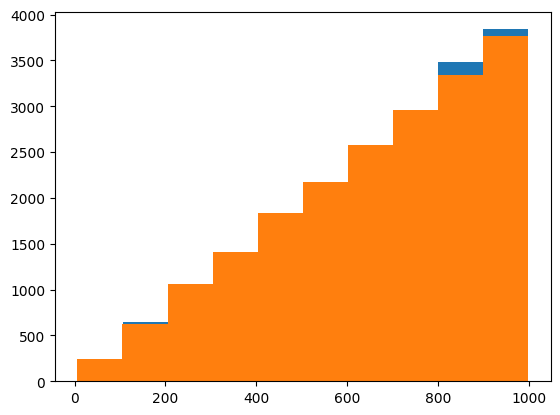

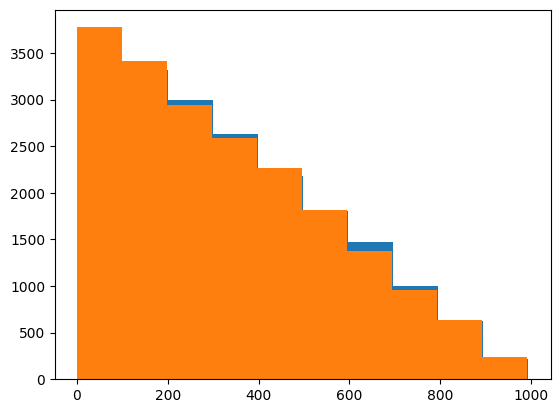

In [44]:
plt.hist(torch.cat(seen_n1s_random).cpu().numpy())
plt.hist(torch.cat(seen_n1s_pregen).cpu().numpy())
plt.show()
plt.hist(torch.cat(seen_n2s_random).cpu().numpy())
plt.hist(torch.cat(seen_n2s_pregen).cpu().numpy())
plt.show()

In [50]:
n = 17
total_rows = 0
total_labels = 0

for batch_idx, (data, labels) in enumerate(training_encoder_data_loaders_pregenerated[n]):
    total_rows += data.shape[0]
    total_labels += labels.shape[0]
print("Pregenerated Training dataset size:", total_rows, total_labels)

total_rows = 0
total_labels = 0
for batch_idx, (data, labels) in enumerate(validation_encoder_data_loaders_pregenerated[n]):
    total_rows += data.shape[0]
    total_labels += labels.shape[0]
print("Pregenerated Validation dataset size:", total_rows, total_labels)

total_rows = 0
total_labels = 0
for batch_idx, (data, labels) in enumerate(testing_encoder_data_loaders_pregenerated[n]):
    total_rows += data.shape[0]
    total_labels += labels.shape[0]
print("Pregenerated Testing dataset size:", total_rows, total_labels)


n = 17
total_rows = 0
total_labels = 0

for batch_idx, (data, labels) in enumerate(training_encoder_data_loaders_random[n]):
    total_rows += data.shape[0]
    total_labels += labels.shape[0]
print("Random Training dataset size:", total_rows, total_labels)

total_rows = 0
total_labels = 0
for batch_idx, (data, labels) in enumerate(validation_encoder_data_loaders_random[n]):
    total_rows += data.shape[0]
    total_labels += labels.shape[0]
print("Random Validation dataset size:", total_rows, total_labels)

total_rows = 0
total_labels = 0
for batch_idx, (data, labels) in enumerate(testing_encoder_data_loaders_random[n]):
    total_rows += data.shape[0]
    total_labels += labels.shape[0]
print("Random Testing dataset size:", total_rows, total_labels)

Pregenerated Training dataset size: 20000 20000
Pregenerated Validation dataset size: 200 200
Pregenerated Testing dataset size: 2000 2000
Random Training dataset size: 20000 20000
Random Validation dataset size: 200 200
Random Testing dataset size: 2000 2000


In [67]:
random_data_mean = torch.zeros(len(training_encoder_data_loaders_random))
random_labl_mean = torch.zeros(len(training_encoder_data_loaders_random))
pregen_data_mean = torch.zeros(len(training_encoder_data_loaders_random))
pregen_labl_mean = torch.zeros(len(training_encoder_data_loaders_random))
for n in range(len(training_encoder_data_loaders_random)):
    for batch_idx, (data, labels) in enumerate(training_encoder_data_loaders_random[n]):
        if n == 0 and batch_idx == 0:
            print("Random Data Type:", data.dtype, labels.dtype)
        random_data_mean[n] += data.mean()
        random_labl_mean[n] += labels.mean()

    for batch_idx, (data, labels) in enumerate(training_encoder_data_loaders_pregenerated[n]):
        if n == 0 and batch_idx == 0:
            print("Pregen Data Type:", data.dtype, labels.dtype)
        pregen_data_mean[n] += data.mean()
        pregen_labl_mean[n] += labels.mean()


Random Data Type: torch.bfloat16 torch.bfloat16
Pregen Data Type: torch.bfloat16 torch.bfloat16


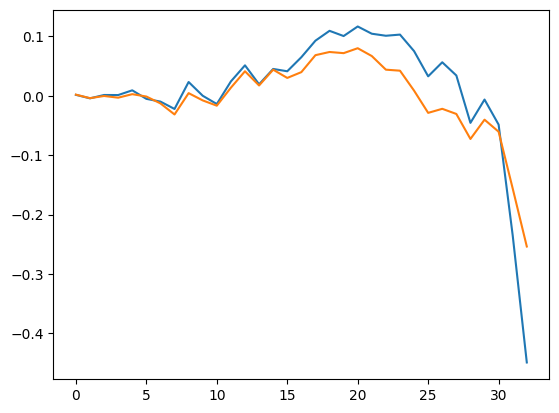

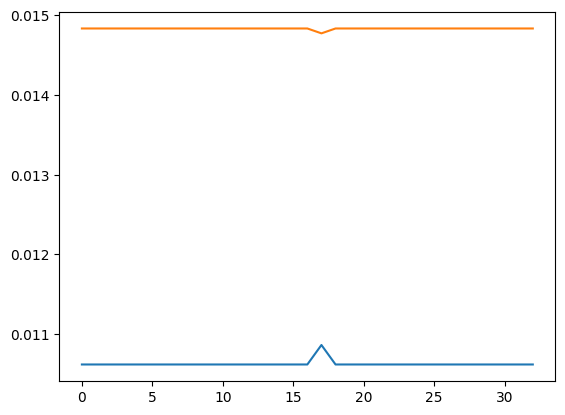

In [74]:
plt.plot(random_data_mean.float().cpu().numpy())
plt.plot(pregen_data_mean.float().cpu().numpy())
plt.show()
plt.plot(random_labl_mean.float().cpu().numpy())
plt.plot(pregen_labl_mean.float().cpu().numpy())
plt.show()

In [56]:
print(random_data_mean, random_labl_mean, pregen_data_mean, pregen_labl_mean)

tensor(0.0938, device='cuda:0') tensor(0.0107, device='cuda:0') tensor(0.0688, device='cuda:0') tensor(0.0148, device='cuda:0')


In [46]:
from collections import Counter

In [ ]:
labels_pregen

In [63]:
seen_pt_counts

{'addition': 0,
 'multiplication': 66,
 'division': 0,
 'modulo': 73,
 'gcd': 57,
 'lcm': 68,
 'square_mod': 49,
 'bitwise_and': 64,
 'bitwise_xor': 79,
 'bitwise_or': 56}

In [54]:
Counter(SE.decode_problem_type(labels_random.float())[0])

Counter({'lcm': 66,
         'multiplication': 68,
         'gcd': 58,
         'bitwise_and': 47,
         'bitwise_or': 70,
         'square_mod': 70,
         'modulo': 57,
         'bitwise_xor': 76})

In [45]:
SE.decode_problem_type(labels_random.float())

(array(['lcm', 'multiplication', 'gcd', 'bitwise_and', 'bitwise_or',
        'square_mod', 'bitwise_or', 'modulo', 'multiplication',
        'square_mod', 'bitwise_xor', 'bitwise_and', 'bitwise_or', 'lcm',
        'gcd', 'bitwise_xor', 'square_mod', 'bitwise_or', 'modulo', 'lcm',
        'square_mod', 'bitwise_or', 'modulo', 'modulo', 'lcm',
        'bitwise_xor', 'square_mod', 'modulo', 'gcd', 'bitwise_and',
        'bitwise_xor', 'bitwise_xor', 'bitwise_or', 'lcm', 'bitwise_or',
        'bitwise_or', 'bitwise_xor', 'bitwise_xor', 'bitwise_xor',
        'square_mod', 'bitwise_and', 'gcd', 'bitwise_and', 'modulo',
        'multiplication', 'lcm', 'square_mod', 'modulo', 'bitwise_xor',
        'bitwise_xor', 'gcd', 'bitwise_and', 'bitwise_xor',
        'multiplication', 'square_mod', 'bitwise_and', 'lcm', 'square_mod',
        'square_mod', 'gcd', 'bitwise_and', 'bitwise_or', 'bitwise_or',
        'multiplication', 'lcm', 'modulo', 'bitwise_or', 'multiplication',
        'multiplication

In [16]:
encoders = torch.nn.ModuleList()
for layer_id in layer_numbers:
    if tokens_to_keep == 1:
        #layer_encoder = Encoder_Deep(layer_id, model_dim, VSA_dim, model_dim*4).to(device)
        layer_encoder = Encoder(layer_id, model_dim, VSA_dim, ).to(device)
    else:
        layer_encoder = LastTokenTransformer(layer_id, model_dim, VSA_dim, num_layers=2, hidden_dim=512).to(device)
    encoders.append(layer_encoder)#, dtype=torch.float32))

print("Trainable parameters per layer:", count_trainable_parameters(layer_encoder)) # Per Layer

optimizers   = [optim.Adam(encoders[n].parameters(), lr=learning_rate) for n in range(len(layer_numbers))]
criterion = nn.MSELoss()
losses     = np.zeros((len(layer_numbers), training_epochs))
val_losses = np.zeros((len(layer_numbers), training_epochs))
running_losses = np.zeros((len(layer_numbers)))


Trainable parameters per layer: 8388608


In [17]:
from collections import Counter


Training dataset size: 20000 20000
Validation dataset size: 200 200
Testing dataset size: 2000 2000


In [19]:
train_pts = []
train_similarities = []
train_all_pt_similarities = []

n1s = []
n2s = []

exponents = torch.tensor([10 ** i for i in range(SE.max_digits)])
for batch_idx, (data, labels) in enumerate(training_encoder_data_loaders[n]):
    pts, similarities, all_pt_similarities = SE.decode_problem_type(labels)
    train_pts += [pts]
    train_similarities += [torch.tensor(similarities)]
    train_all_pt_similarities += [torch.tensor(all_pt_similarities)]
    actual_n1  = (SE.decode_digits(labels.type_as(SE.vectors[SE.VSA_n1]), SE.VSA_n1) * exponents).sum(axis=1)
    actual_n2  = (SE.decode_digits(labels.type_as(SE.vectors[SE.VSA_n2]), SE.VSA_n2) * exponents).sum(axis=1)

    n1s += [actual_n1]
    n2s += [actual_n2]
    

In [20]:
torch.cat(n1s).cpu().numpy()[:100]

array([382, 978, 652, 460, 991, 489, 913, 662, 179, 496, 277, 393, 203,
       517, 890, 706, 728, 279, 930, 469, 846, 989, 732, 295, 287, 526,
       994, 627, 343, 403, 996, 681, 958, 310, 612, 758, 774, 891, 479,
       730, 261, 638, 539, 804, 551, 877, 720, 263, 637, 228, 505, 632,
       926, 652, 123, 889, 790, 935, 839, 969, 816, 761, 717, 646, 870,
       579, 915, 962, 975, 886, 802, 916, 118, 700, 799, 586, 846, 937,
       583, 822, 759, 852, 658, 485, 698, 668, 325, 710, 709, 127, 663,
       863, 254, 453, 450, 705, 626, 586, 251, 506])

In [21]:
torch.cat(n2s).cpu().numpy()[:100]

array([375, 134, 541, 122, 316, 409,  53, 641, 122, 392,  37, 240,  40,
       472, 674, 342, 597,  22, 555, 181, 793, 760,  73, 248, 272, 317,
        70, 380,  61,  91, 305, 438, 709,  14,  85, 145, 511, 580, 140,
       348, 258, 347, 408, 441, 402, 517, 287, 128, 251, 187,  19, 422,
       518, 235,  98,  99, 696, 499, 212,  68, 140, 429, 339, 203, 557,
       214, 579, 543, 166, 856, 745, 176,  70, 110, 539, 274, 489, 506,
       232, 181, 652, 301, 465, 341, 624, 404,  53, 362, 141,  14, 172,
       565, 217,  97, 346,  42, 349, 258,  43, 276])

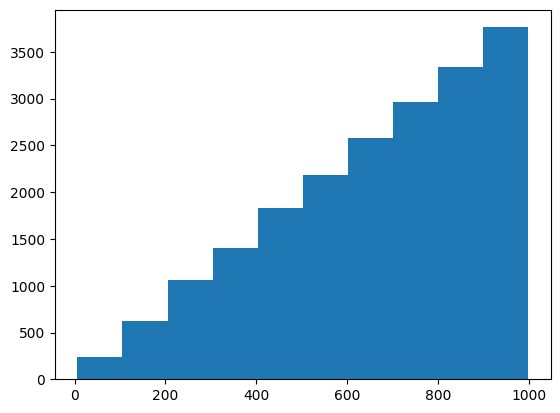

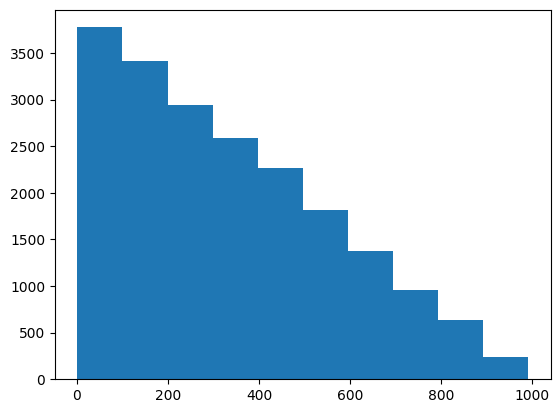

In [22]:
plt.hist(torch.cat(n1s).cpu().numpy())
plt.show()
plt.hist(torch.cat(n2s).cpu().numpy())
plt.show()

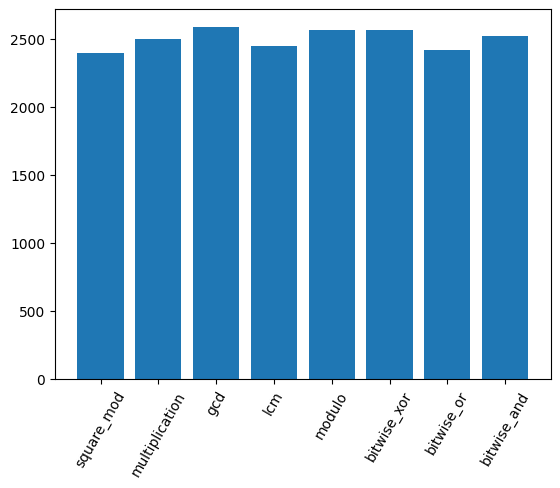

In [23]:
category_counts = Counter(np.concatenate(train_pts))

plt.bar(category_counts.keys(), category_counts.values())
plt.xticks(rotation=60)
plt.show()

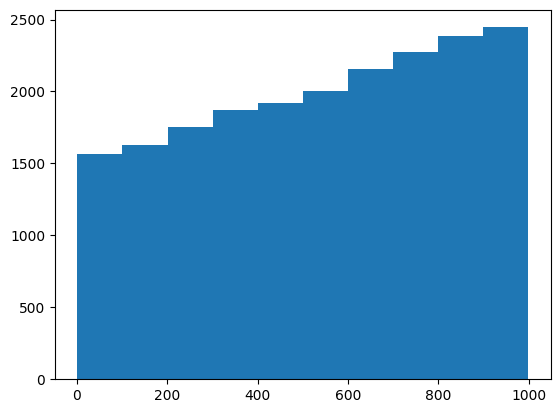

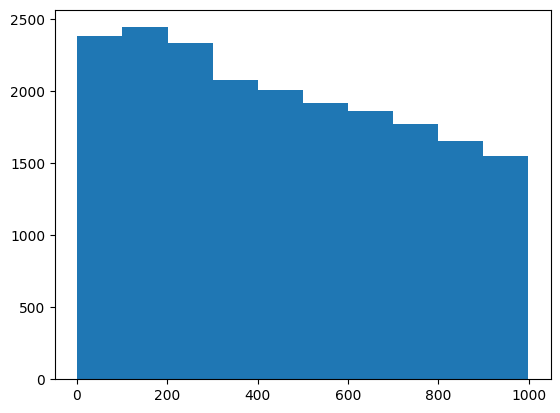

In [24]:
df = pd.read_csv("~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_20000_training_samples.csv")
plt.hist(df.x)
plt.show()
plt.hist(df.y)
plt.show()

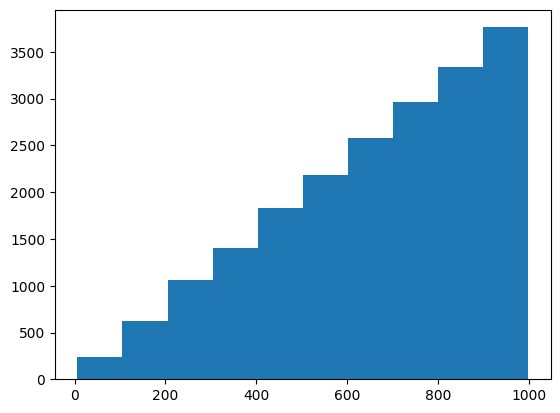

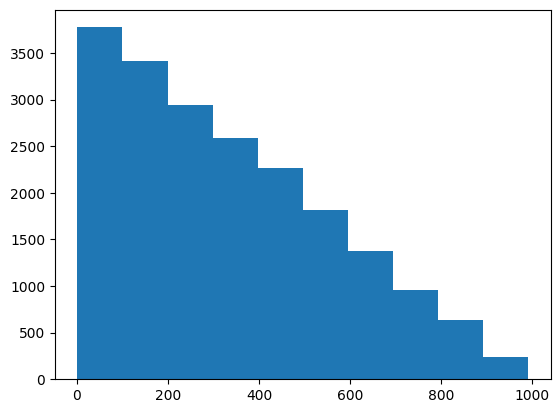

In [25]:
df = pd.read_csv("~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_20000_training_samples.csv")
plt.hist(df.x)
plt.show()
plt.hist(df.y)
plt.show()